# ICS 2405: Knowledge-Based Systmes
## evalaution of classification models:


> ##### CONTEXT:  
 > this involved valuation techniques that are appropriate for classifiers.
 > and we use different metrics that help identify different types of mistakes that classifiers make. we’ll also look at some graphical methods for evaluating and comparing classifiers

In [1]:
# setup
from mlwpy import *
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import (datasets, model_selection as skms, linear_model, metrics, neighbors, naive_bayes)

In [2]:
iris = datasets.load_iris()
tts = skms.train_test_split(iris.data, iris.target, test_size=.33, random_state=21)

(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = tts

### baseline classifiers:
baseline models are a standard of comparison; they will be used as the basis for comparisons.

we evaluate and figure out what best model to go wwith by comparing against the simplest ideas we can come up with: baseline methods.
`sklearn` calls these **dummy methods**. we can imagine **four levels** of learning systems:
1. **baseline methods** — prediction based on simple statistics or random guesses,
2. **simple off-the-shelf learning methods** — predictors that are generally less resource-intensive,
3. **complex off-the-shelf learning methods** — predictors that are generally more resource-intensive, and
4. **customized, boutique learning methods**.

### decision:
the most *basic*, **baseline systems** help us decide **if we need a complicated system** and **if that system is better than
something primitive**.

> **sklearn**:
> **four baseline classification methods**. two baseline methods are random and other two return a constant value;    

the **random methods** are:
- `uniform`: choose evenly among the target classes based on the
number of classes
- `stratified`: choose evenly among the target classes based on
frequency of those classes.  


the two **constant methods** are:  
- `constant`: return one target class that we’ve picked out and
- `most_frequent`: return the single most likely class. `most_frequent` is also available under the name `prior`.

##### comparing the baseline strategies above:  

In [3]:
# normal usage: build-fit-predict-evaluate
baseline = dummy.DummyClassifier(strategy="most_frequent")
baseline.fit(iris_train_ftrs, iris_train_tgt)
base_preds = baseline.predict(iris_test_ftrs)

base_acc = metrics.accuracy_score(base_preds, iris_test_tgt)
print(base_acc)

0.3


In [4]:
strategies = ['constant', 'uniform', 'stratified', 'prior', 'most_frequent']
# set up args to create different DummyClassifier strategies
baseline_args = [{'strategy':s} for s in strategies]
baseline_args[0]['constant'] = 0 # class 0 is setosa
accuracies = []

for bla in baseline_args:
    baseline = dummy.DummyClassifier(**bla)
    baseline.fit(iris_train_ftrs, iris_train_tgt)
    base_preds = baseline.predict(iris_test_ftrs)
    accuracies.append(metrics.accuracy_score(base_preds, iris_test_tgt))
    
display(pd.DataFrame({'accuracy':accuracies}, index=strategies))

,accuracy
constant,0.3600
uniform,0.3800
stratified,0.3400
prior,0.3000
most_frequent,0.3000


### metrircs for classification:
#### 1 - accuracy(covered prior to this point):
- we'll add others below:

In [13]:
# sklearn has a plethora of metrics to choose from:
import textwrap
from sklearn.metrics import get_scorer_names

print(textwrap.fill(str(sorted(get_scorer_names())), width=70))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score',
'average_precision', 'balanced_accuracy', 'completeness_score',
'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score',
'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples',
'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score',
'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples',
'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score',
'neg_brier_score', 'neg_log_loss', 'neg_max_error',
'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error',
'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance',
'neg_mean_squared_error', 'neg_mean_squared_log_error',
'neg_median_absolute_error', 'neg_negative_likelihood_ratio',
'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error',
'normalized_mutual_info_score', 'positive_likelihood_ratio',
'precision', 'precision_macro', 'precision_micro',
'precision_samples', 'precision_weighted', 'r2', 'rand_score',
'recall', 'recall_m

### scorer for a particular classifier:
how can we identify the scorer used for a particular
classifier—say, k-NN? (you get a mean accuracy in this case below)

In [14]:
from sklearn import neighbors

knn = neighbors.KNeighborsClassifier()
# help(knn.score) # verbose, but complete
print(knn.score.__doc__.splitlines()[0])
print('\n---and---\n')
print("\n".join(knn.score.__doc__.splitlines()[-6:]))



---and---

    Sample weights.

Returns
-------
score : float
    Mean accuracy of ``self.predict(X)`` w.r.t. `y`.


# **BEYOND `accuracy`: classification metrics**

## **Core Problem with Accuracy**
- **Accuracy = (correct predictions) / (total predictions)**
- **Fatal flaw with imbalanced data:** example - 98 healthy / 2 sick patients
  - Dumb classifier: "predict everyone is healthy" → **98% accuracy!**
  - But **finds 0 sick patients** → complete failure for the actual task
- **wraps:** accuracy alone can be dangerously misleading

### confusion metrics:


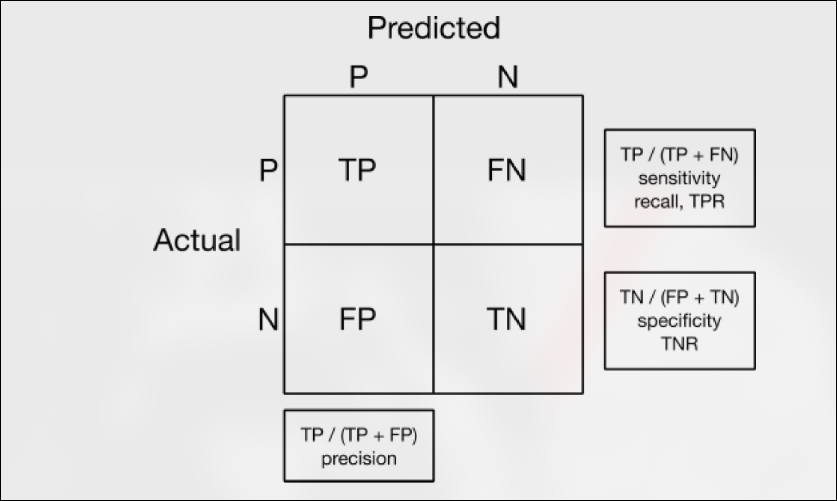

## **The Confusion Matrix (2×2 for binary classification)**

### **Setup:**
- **Positive (P):** The "interesting" case we're trying to detect
- **Negative (N):** The other case
- **True/False:** Whether prediction matched reality

### **Confusion Matrix Structure:**

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

---

## **salient: from confusion matrix:**

**From Reality's perspective:**
- **RealP = TP + FN** (all actual positives)
- **RealN = FP + TN** (all actual negatives)

**from predictions' perspective:**
- **PredP = TP + FP** (All predicted positives)
- **PredN = FN + TN** (All predicted negatives)

---

## **Essential Metrics Derived from Confusion Matrix:**

### **1. Recall (Sensitivity / True Positive Rate - TPR)**
```
Recall = TP / RealP = TP / (TP + FN)
```
- **Question:** "Of all the actual positives, how many did we catch?"
- **Focus:** **Minimizing False Negatives** (missed cases)
- **When to care:** Medical testing, fraud detection (don't want to miss sick/risky cases)
- **Synonyms:** Sensitivity, Hit Rate, True Positive Rate

### **2. Precision**
```
Precision = TP / PredP = TP / (TP + FP)
```
- **Question:** "Of all the things we labeled positive, how many were actually positive?"
- **Focus:** **Minimizing False Positives** (false alarms)
- **When to care:** Spam detection, search results (don't want irrelevant "hits")

### **3. Specificity (True Negative Rate - TNR)**
```
Specificity = TN / RealN = TN / (FP + TN)
```
- **Question:** "Of all the actual negatives, how many did we correctly identify as negative?"
- **Focus:** How good the test is at **not raising false alarms**
- **Synonyms:** True Negative Rate

---

## **Important Relationships:**
- **Recall + False Negative Rate = 1**  
  `TP/(TP+FN) + FN/(TP+FN) = 1`
- **Specificity + False Positive Rate = 1**  
  `TN/(FP+TN) + FP/(FP+TN) = 1`


---

## **Memorable Examples:**
1. **Medical test:** Positive = disease present  
   - High **recall** = don't miss sick people  
   - High **precision** = don't scare healthy people unnecessarily  

2. **Pot on stove:** Positive = hot  
   - **False Positive:** Think it's hot when it's cold → might not clean it (trouble)  
   - **False Negative:** Think it's cold when it's hot → get burned (pain)

---

## **wraps:**
- **Accuracy alone → insufficient for imbalanced data**
- **Recall vs Precision trade-off:** What's worse in your application?  
  - Missing real cases (low recall)?  
  - False alarms (low precision)?
- **Always visualize confusion matrix** to see where errors occur


In [15]:
tgt_preds = (neighbors.KNeighborsClassifier()
    .fit(iris_train_ftrs, iris_train_tgt)
    .predict(iris_test_ftrs))

print("accuracy:", metrics.accuracy_score(iris_test_tgt, tgt_preds))

cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)

print("confusion matrix:", cm, sep="\n")

accuracy: 0.94
confusion matrix:
[[18  0  0]
 [ 0 16  1]
 [ 0  2 13]]


#### confusion matrix as a table:

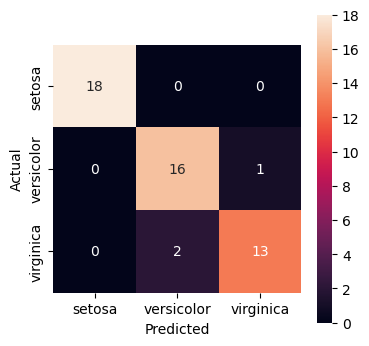

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
ax = sns.heatmap(cm, annot=True, square=True, xticklabels=iris.target_names, yticklabels=iris.target_names)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual');

##### salient:
- we can see we get it 100% right. though satosa is easy to some degree.
- we have some mixed signals on `versicolor` and `virginica`, but we don’t do too badly
there either.

- wraps: the errors with versicolor and virginica are confined to misclassifying
between those two classes. We don’t get any cross-classification back into setosa. We can
think about setosa as being a clean category of its own. the two *`v`* species have some
overlap that is harder to sort out.

## multiclass averageing:

#### context: 
- **problem:** precision/recall formulas are designed for 2 classes
- **solution:** use **averaging methods** to combine per-class metrics  

>the averaging methods in sklearn are listed out below:

### **1. macro averaging**
```
macro = average(metric₁, metric₂, metric₃, ...)
```
- **process:** calculate metric for each class → average them equally
- **example from iris:** 
  - versicolor: 16/18 = 0.89
  - virginica: 13/14 = 0.93  
  - setosa: 18/18 = 1.0
  - **macro precision** = (0.89 + 0.93 + 1.0)/3 = **0.939**
- **characteristics:**
  - treats all classes equally regardless of class size
  - good when all classes are equally important

### **2. micro averaging**
```
micro = total_correct_predictions / total_predictions
```
- **process:** Pool all predictions together, then compute metric
- **example from iris:** (18+16+13)/50 = **0.94**
- **characteristics:**
  - equivalent to **overall accuracy** for precision/recall
  - weighs each sample equally (not each class)
  - favors larger classes

### **3. weighted averaging**
```
weighted = average(metric₁×weight₁, metric₂×weight₂, ...)
```
- **Process:** Macro average, but weighted by **support** (number of true instances per class)
- **Support** = counts in each row of confusion matrix
- **Example from iris:** Weights = [18, 17, 15]
- **Useful when:** Classes are imbalanced

---

## **`classification_report()` - quick aside**
```python
print(metrics.classification_report(y_true, y_pred))
```
**putput includes:**
- per-class precision, recall, f1-score
- **support** (actual counts of each class)
- three averages: micro, macro, weighted

---

## **f1-score: harmonic mean of `precision` & `recall`**

### **why harmonic mean?**
- **arithmetic mean:** (P+R)/2 → treats P=0.01, R=0.99 as "average" 0.5 (misleading!)
- **harmonic mean:** 2PR/(P+R) → penalizes extreme imbalance
- **intuition:** better measure when both metrics need to be high

### **F1 Formula:**
```
F1 = 2 × (precision × recall) / (precision + recall)
```
**alternative form:** `F1 = harmonic_mean(precision, recall)`

### **why use F1?**
- **single metric** balancing precision and recall
- **useful when:** need to optimize both false positives AND false negatives
- **interpretation:** 
  - F1 = 1 → perfect precision and recall
  - F1 = 0 → either precision or recall is 0

---

## **wraps:**
1. **multiclass metrics need averaging** (macro/micro/weighted)
2. **choose averaging method based on your goal:**
   - **macro:** all classes equal importance
   - **micro:** all samples equal importance (≈ accuracy)
   - **weighted:** account for class imbalance
3. **f1-score** = balanced measure of precision & recall
   - harmonic mean → penalizes extreme values
   - better than simple average for imbalanced cases
4. **always check `classification_report()`** for complete picture

**I remember:** `Fβ` exists for precision/recall tradeoffs (β > 1 favors recall, β < 1 favors precision)




### **compute averages:**
```python
# macro average
macro_prec = metrics.precision_score(y_true, y_pred, average='macro')

# micro average  
micro_prec = metrics.precision_score(y_true, y_pred, average='micro')

# manual calculation of micro:
cm = metrics.confusion_matrix(y_true, y_pred)
micro_manual = np.diag(cm).sum() / cm.sum()
```

### **complete classification report:**
```python
print(metrics.classification_report(y_true, y_pred))
# shows precision, recall, F1 per class + averages
```


In [17]:
macro_prec = metrics.precision_score(iris_test_tgt, tgt_preds, average='macro')

print("macro:", macro_prec)
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)

n_labels = len(iris.target_names)
print("should equal 'macro avg':",
      # correct column # columns
      (np.diag(cm) / cm.sum(axis=0)).sum() / n_labels)

macro: 0.9391534391534391
should equal 'macro avg': 0.9391534391534391


In [18]:
print("micro:", metrics.precision_score(iris_test_tgt, tgt_preds, average='micro'))
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)

print("should equal avg='micro':",
      # TP.sum() / (TP&FP).sum() -->
      # all correct / all preds
      np.diag(cm).sum() / cm.sum())

micro: 0.94
should equal avg='micro': 0.94


In [19]:
print(metrics.classification_report(iris_test_tgt, tgt_preds))
# average is a weighted macro average (see text)
# verify sums-across-rows
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)

print("row counts equal support:", cm.sum(axis=1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      0.94      0.91        17
           2       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50

row counts equal support: [18 17 15]


## `ROC` CURVES:

## **core tenet: to understand classification with confidence scores**
- **beyond simple labels:** classifiers can output **probabilities/scores** of being in a class
- **threshold:** cutoff value that determines "positive" vs "negative" prediction
- **salient:** by adjusting the threshold, we can control the tradeoff between **false positives** and **false negatives**

---

## **ROC curve: visualizing the tradeoff**

### **What is ROC?**
- **ROC** = Receiver Operating Characteristic
- **graph:** True Positive Rate (TPR/Recall) vs False Positive Rate (FPR)
- **each point:** Represents a different confusion matrix at a specific threshold

### **understanding the graph:**
- **X-axis:** False Positive Rate (FPR) = `FP/(FP+TN)` = 1 - Specificity
- **Y-axis:** True Positive Rate (TPR) = `TP/(TP+FN)` = Recall/Sensitivity
- **diagonal line (y=x):** random guessing (coin flip) - worst case
- **top-left corner (0,1):** perfect classifier
- **movement along curve:** adjusting threshold changes tradeoff

### **threshold movement:**
- **low threshold (easy to be positive):** → top-right of graph
  - High TPR (catch most positives) but also high FPR (many false alarms)
- **High threshold (strict to be positive):** → Bottom-left of graph  
  - Low FPR (few false alarms) but also low TPR (miss many positives)

---

## **key patterns in ROC graphs:**

1. **diagonal line (y=x):** random guessing → **AUC = 0.5**
2. **perfect classifier:** follows left border then top border → **AUC = 1.0**
3. **better classifier:** closer to top-left corner
4. **comparing classifiers:** one curve dominating another (closer to top-left) is better overall


## **practical code implementation:**

### **binary Classification Example:**
```python
# 1. convert to binary problem (e.g., "is versicolor?")
is_versicolor = iris.target == 1

# 2. get probability scores (not just labels)
gnb = GaussianNB()
prob_scores = gnb.fit(X_train, y_train).predict_proba(X_test)[:, 1]

# 3. calculate ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, prob_scores)

# 4. calculate AUC
auc_score = metrics.auc(fpr, tpr)
```

### **Visualizing ROC:**
```python
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, 'o--', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR/Recall)')
plt.legend()
plt.title('ROC Curve')
```

##### binary ROC:

In [23]:
# warning: this is 1 "one" not l "ell"
is_versicolor = iris.target == 1
tts_1c = skms.train_test_split(iris.data, is_versicolor, test_size=.33, random_state = 21)

(iris_1c_train_ftrs, iris_1c_test_ftrs, iris_1c_train_tgt, iris_1c_test_tgt) = tts_1c
# build, fit, predict (probability scores) for NB model

gnb = naive_bayes.GaussianNB()
prob_true = (gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgt).predict_proba(iris_1c_test_ftrs)[:, 1]) # [:, 1]=="True"

FPR : [0.     0.     0.     0.0606 0.0606 0.1212 0.1212 0.1818 1.    ]
TPR : [0.     0.0588 0.8824 0.8824 0.9412 0.9412 1.     1.     1.    ]


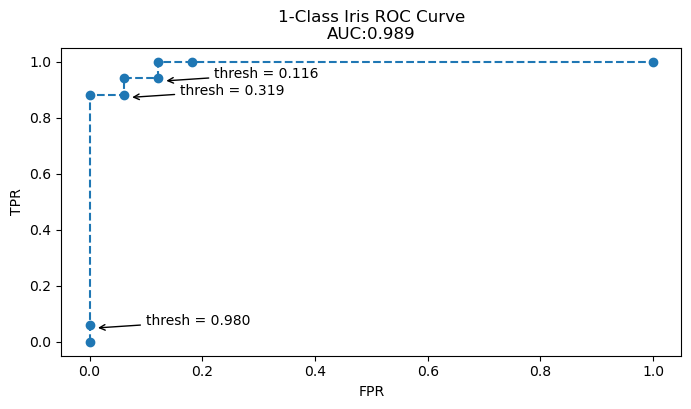

In [24]:
fpr, tpr, thresh = metrics.roc_curve(iris_1c_test_tgt, prob_true)

auc = metrics.auc(fpr, tpr)

print("FPR : {}".format(fpr),
"TPR : {}".format(tpr), sep='\n')

# create the main graph
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fpr, tpr, 'o--')
ax.set_title("1-Class Iris ROC Curve\nAUC:{:.3f}".format(auc))
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");


# do a bit of work to label some points with their
# respective thresholds
investigate = np.array([1, 3, 5])
for idx in investigate:
    th, f, t = thresh[idx], fpr[idx], tpr[idx]
    ax.annotate('thresh = {:.3f}'.format(th),xy=(f+.01, t-.01), xytext=(f+.1, t),arrowprops = {'arrowstyle':'->'})

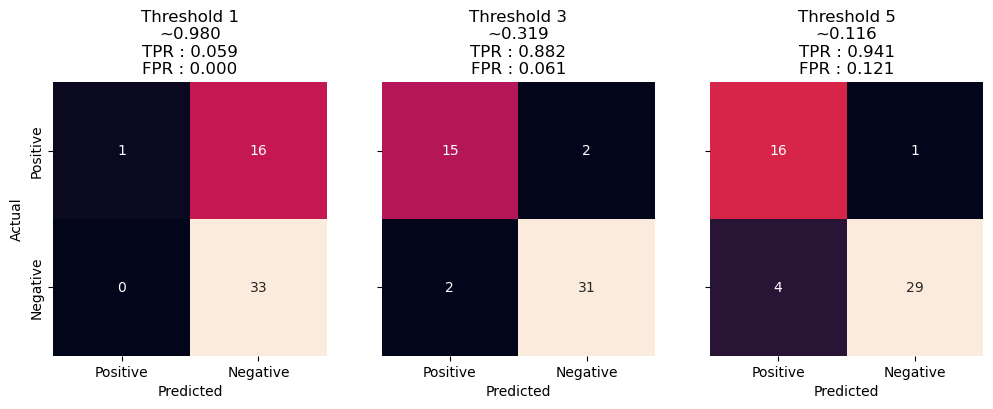

In [25]:
title_fmt = "Threshold {}\n~{:5.3f}\nTPR : {:.3f}\nFPR : {:.3f}"

pn = ['Positive', 'Negative']
add_args = {'xticklabels': pn,
            'yticklabels': pn,
            'square':True}


fig, axes = plt.subplots(1, 3, sharey = True, figsize=(12, 4))
for ax, thresh_idx in zip(axes.flat, investigate):

    preds_at_th = prob_true < thresh[thresh_idx]
    cm = metrics.confusion_matrix(1-iris_1c_test_tgt, preds_at_th)

    sns.heatmap(cm, annot=True, cbar=False, ax=ax, **add_args)
    
    ax.set_xlabel('Predicted')
    ax.set_title(title_fmt.format(thresh_idx, 
                                  thresh[thresh_idx], 
                                  tpr[thresh_idx],
                                  fpr[thresh_idx]))

axes[0].set_ylabel('Actual');
# note: e.g. for threshold 3
# FPR = 1-spec = 1 - 31/(31+2) = 1 - 31/33 = 0.0606..

---

## **AUC: Area Under the(ROC)Curve**

### **What is AUC?**
- Single number summarizing entire ROC curve
- **Range:** 0.5 (random) to 1.0 (perfect)
- **Interpretation:** Probability that classifier ranks random positive higher than random negative

### **AUC Interpretation:**
- **AUC = 0.5:** No better than random guessing
- **AUC = 0.7-0.8:** Acceptable
- **AUC = 0.8-0.9:** Excellent  
- **AUC > 0.9:** Outstanding
- **AUC = 1.0:** Perfect separation

### **Limitations of AUC:**
- **single number** hides threshold-specific performance
- different classifiers might cross: better at some thresholds, worse at others

---

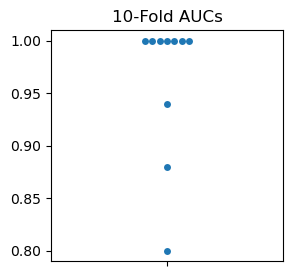

In [26]:
fig,ax = plt.subplots(1, 1, figsize=(3, 3))

model = neighbors.KNeighborsClassifier(3)
cv_auc = skms.cross_val_score(model, iris.data, iris.target==1,
                              scoring='roc_auc', cv=10)

ax = sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold AUCs');

---

## **Multiclass ROC with One-vs-Rest (OvR)**

### **Challenge:** ROC is inherently binary
### **Solution:** One-vs-Rest approach

```python
# 1. Binarize labels for each class
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y, classes=[0, 1, 2])  # 3 columns: is_class_0?, is_class_1?, is_class_2?

# 2. Train OvR classifier
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(KNeighborsClassifier())
ovr_clf.fit(X_train, y_train_bin)

# 3. Get probability scores for each class
y_scores = ovr_clf.predict_proba(X_test)  # 3 probability columns

# 4. Plot ROC for each class
for i in range(3):
    fpr, tpr, _ = metrics.roc_curve(y_test_bin[:, i], y_scores[:, i])
    auc = metrics.auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} vs Rest (AUC={auc:.2f})')
```


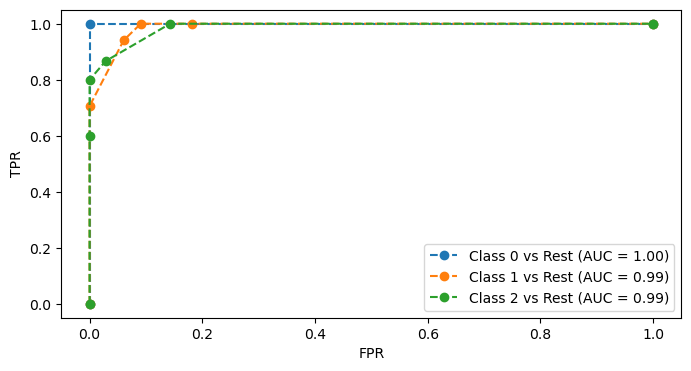

In [29]:
import sklearn.preprocessing as skpre
import sklearn.multiclass as skmulti 

iris_multi_tgt = skpre.label_binarize(iris.target, classes=[0, 1, 2])
# im --> "iris multi"
(im_train_ftrs, im_test_ftrs, im_train_tgt, im_test_tgt) = skms.train_test_split(iris.data, iris_multi_tgt,
                                                                                 test_size=.33,
                                                                                 random_state=21)

# knn wrapped up in one-versus-rest (3 classifiers)
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
ovr_knn = skmulti.OneVsRestClassifier(knn)
pred_probs = (ovr_knn.fit(im_train_ftrs, im_train_tgt)
    .predict_proba(im_test_ftrs))


# make ROC plots
lbl_fmt = "Class {} vs Rest (AUC = {:.2f})"
fig,ax = plt.subplots(figsize=(8, 4))

for cls in [0, 1, 2]:
    fpr, tpr, _ = metrics.roc_curve(im_test_tgt[:,cls],
                                    pred_probs[:,cls])
    label = lbl_fmt.format(cls, metrics.auc(fpr,tpr))
    ax.plot(fpr, tpr, 'o--', label=label)

ax.legend()
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");

**Summary:**

All three classifiers perform well with minimal errors. Class 0 (setosa) achieves excellent results as expected, since it's easily separable. The other two classes also achieve high True Positive Rates (TPR) with low False Positive Rates (FPR < 0.18).

**Practical threshold selection strategy:**
- Set an acceptable TPR, then optimize for the best FPR at that level
- Or reverse: set an acceptable FPR, then optimize for TPR
- Example use case: In medical diagnosis, you might prioritize low FPR to avoid subjecting healthy patients to unnecessary, invasive, and expensive procedures—only flagging cases with sufficiently high disease probability.


---
## GENERAL:
## **Threshold Selection Strategy:**

### **How to choose optimal threshold?**
1. **Identify acceptable TPR/FPR tradeoff** based on application:
   - **Medical test:** High TPR more important (don't miss sick patients)
   - **Spam filter:** Low FPR more important (don't flag legitimate emails)
2. **Find threshold** on ROC curve that meets your requirements
3. **Example:** "I need TPR ≥ 0.9 with lowest possible FPR"

### **Practical threshold selection:**
```python
#fFind threshold that gives TPR closest to 0.9
desired_tpr = 0.9
idx = np.argmin(np.abs(tpr - desired_tpr))
optimal_threshold = thresholds[idx]
print(f"Threshold for TPR≈0.9: {optimal_threshold:.3f}")
print(f"Corresponding FPR: {fpr[idx]:.3f}")
```

---

## **Cross-Validated AUC (More Robust):**
```python
from sklearn.model_selection import cross_val_score

model = KNeighborsClassifier(n_neighbors=3)
cv_auc_scores = cross_val_score(model, X, y_binary, 
                               scoring='roc_auc', cv=10)

# Visualize variability
import seaborn as sns
sns.swarmplot(data=cv_auc_scores, orient='v')
plt.title('10-Fold Cross-Validation AUC Scores')
```

---

## **WRAPS:**

### **ROC Curve:**
- **X-axis:** FPR (1-Specificity) → How many negatives incorrectly flagged?
- **Y-axis:** TPR (Recall) → How many positives correctly caught?
- **Better classifier:** Curve closer to top-left
- **Random guessing:** Diagonal line

### **AUC:**
- **Summary metric:** Higher = better overall performance
- **Not threshold-specific:** Averages across all thresholds
- **Use with caution:** Can mask important threshold-specific behaviors

### **Practical Applications:**
1. **Medical diagnosis:** Favor high TPR (catch all sick patients)
2. **Fraud detection:** Favor low FPR (minimize false accusations)
3. **Search engines:** Balance between TPR (find relevant results) and FPR (avoid irrelevant results)

### **I Remember:**
- **ROC/AUC for binary classification** directly
- **Multiclass:** Use One-vs-Rest or One-vs-One approaches
- **Always visualize ROC curve** - don't rely solely on AUC number
- **Choose threshold based on application needs**, not just maximum AUC
---

# mutilearners, one-versus-rest, roc

## **Core Idea: Pairwise Class Comparisons**
- **One-vs-Rest (OvR):** Each class vs ALL other classes → n classifiers for n classes
- **One-vs-One (OvO):** Each class vs EACH OTHER class → n(n-1)/2 classifiers

---

## **How OvO Works:**
1. **For n classes:** Create a classifier for every possible pair (i vs j)
2. **Number of classifiers:** n(n-1)/2
   - Example: 3 classes → 3×2/2 = **3 classifiers**
3. **Voting scheme:** Each classifier votes for one of its two classes
4. **Final prediction:** Class with most votes wins (like round-robin tournament)

---

## **Code Example (OvO):**
```python
from sklearn.multiclass import OneVsOneClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create OvO wrapper
knn = KNeighborsClassifier(n_neighbors=5)
ovo_knn = OneVsOneClassifier(knn)

# Fit and get decision scores
ovo_knn.fit(X_train, y_train)
pred_scores = ovo_knn.decision_function(X_test)  # Not probabilities!

# Each row: scores for each class
# Higher score = more votes for that class
# Final prediction = class with highest score
predicted_class = pred_scores.argmax(axis=1)
```

---

## **Key Differences: OvR vs OvO**

| Aspect | One-vs-Rest (OvR) | One-vs-One (OvO) |
|--------|-------------------|------------------|
| **# Classifiers** | n | n(n-1)/2 |
| **Training Data** | All data each time | Only data for the two classes |
| **Problem Type** | "Is it class X?" | "Is it class X or class Y?" |
| **Output** | Probabilities | Decision scores (not probabilities) |
| **Use Case** | Works for any classifier | Only for classifiers that support it |

---

## **Multiclass AUC: The Hand & Till M Statistic**

### **Problem:** ROC/AUC is inherently binary
### **Solution:** Pairwise AUC averaging

### **Hand & Till M Method:**
1. **For each pair of classes (i, j):**
   - Treat i as positive, j as negative → calculate AUC₁
   - Treat j as positive, i as negative → calculate AUC₂
   - Average: (AUC₁ + AUC₂)/2
2. **Average over all pairs**
3. **Result:** Single AUC-like value for multiclass

### **Intuition:** 
"How well does the classifier rank a random example from class i vs a random example from class j?"

---

## **Hand & Till M Implementation:**
```python
def hand_and_till_M_statistic(y_true, y_probs):
    classes = np.unique(y_true)
    n_classes = len(classes)
    total = 0
    
    # For each pair of classes
    for i, j in combinations(classes, 2):
        # Get examples from either class i or j
        mask = (y_true == i) | (y_true == j)
        y_true_pair = y_true[mask]
        y_probs_pair = y_probs[mask]
        
        # AUC when i is positive, j is negative
        auc_ij = roc_auc_score(y_true_pair == i, y_probs_pair[:, i])
        
        # AUC when j is positive, i is negative  
        auc_ji = roc_auc_score(y_true_pair == j, y_probs_pair[:, j])
        
        total += (auc_ij + auc_ji) / 2  # Average for this pair
    
    # Final M statistic
    M = total / (n_classes * (n_classes - 1) / 2)
    return M
```

---

## **Making Custom Metrics Work with sklearn:**

### **Using `make_scorer()`:**
```python
from sklearn.metrics import make_scorer

# Turn our function into a scorer
htm_scorer = make_scorer(hand_and_till_M_statistic, 
                         needs_proba=True)

# Use in cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, 
                           scoring=htm_scorer, cv=10)
```

### **Key parameters for `make_scorer`:**
- `needs_proba=True`: Function expects probability scores
- `needs_threshold=False`: Function expects decision scores
- `greater_is_better=True`: Higher score = better performance

---

## **When to Use OvO vs OvR:**

### **Choose OvO when:**
- Classes are balanced
- Dataset is large enough to handle many classifiers
- You care about pairwise separability
- Classifier only works with binary problems

### **Choose OvR when:**
- Classes are imbalanced  
- Dataset is smaller
- You want probability outputs
- Simpler interpretation needed

---

## **Practical Example with Iris Dataset:**
```python
# OvO for 3-class iris
# 3 classifiers: (0vs1, 0vs2, 1vs2)
ovo = OneVsOneClassifier(KNeighborsClassifier())
ovo.fit(X_train, y_train)

# Decision scores matrix
scores = ovo.decision_function(X_test)
# Shape: (n_samples, n_classes)
# Each column = "strength" of that class

# Compare with actual binarized targets
y_test_bin = label_binarize(y_test, classes=[0,1,2])
# Shape: (n_samples, n_classes) with 0/1 indicators
```

---

## **Wraps:**

### **OvO Fundamentals:**
1. **Number of classifiers:** n(n-1)/2 (triangular number)
2. **Voting mechanism:** Each classifier votes → most votes wins
3. **Decision scores:** Not probabilities (can be negative, unbounded)
4. **Final prediction:** `argmax` of scores across classes

### **Hand & Till M Statistic:**
1. **Purpose:** Multiclass extension of AUC
2. **Method:** Average of pairwise AUCs
3. **Range:** 0.5 (random) to 1.0 (perfect)
4. **Interpretation:** "How well does classifier rank examples between any two classes?"

### **Implementation Notes:**
- Use `OneVsOneClassifier` wrapper for OvO
- Use `make_scorer()` for custom metrics in CV
- `decision_function()` gives OvO scores (not `predict_proba()`)
- Hand & Till method uses actual probabilities from a single multiclass classifier

### **Important:**
- **OvR:** "Am I this ONE thing?" → n questions
- **OvO:** "Am I more THIS or THAT?" → n(n-1)/2 comparisons
- **AUC extension:** Average all "this vs that" battless

---
# **Precision-Recall Curves (PRC)**

## **Core Concept: Precision vs Recall Tradeoff**
- **Precision:** "Value of a positive prediction" → TP / (TP + FP)
- **Recall:** "Effectiveness on actual positives" → TP / (TP + FN) (same as sensitivity)
- **Precision-Recall Curve:** Shows tradeoff as threshold changes


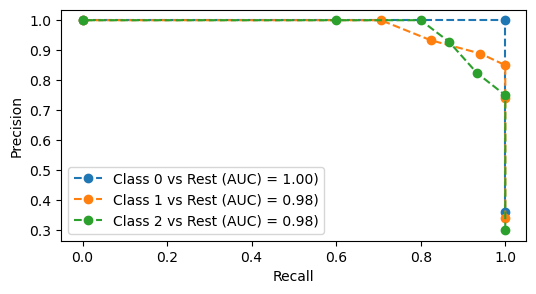

In [30]:
fig,ax = plt.subplots(figsize=(6, 3))
for cls in [0, 1, 2]:
    prc = metrics.precision_recall_curve
    precision, recall, _ = prc(im_test_tgt[:,cls],pred_probs[:,cls])
    prc_auc = metrics.auc(recall, precision)
    label = "Class {} vs Rest (AUC) = {:.2f})".format(cls, prc_auc)
    ax.plot(recall, precision, 'o--', label=label)
ax.legend()
ax.set_xlabel('Recall')
ax.set_ylabel('Precision');

## **Key Difference from ROC Curves:**

| Aspect | ROC Curve | Precision-Recall Curve |
|--------|-----------|------------------------|
| **Axes** | TPR (Recall) vs FPR | Precision vs Recall |
| **Perfect point** | Top-left (0,1) | Top-right (1,1) |
| **Random baseline** | Diagonal line | Horizontal line at prevalence |
| **Movement** | Always up/right (monotonic) | Can move up/down/left/right |
| **Focus** | Both classes (TPR & FPR) | Only positive class (Precision & Recall) |

---

## **Why PRC Can Regress (Move Backwards):**
- **ROC components (TPR & FPR):** Both come from row totals → trade directly
- **PRC components (Precision & Recall):** One from column, one from row → independent

### **Example: Raising threshold (making predictions stricter)**
```
Initial:
PredP  PredN
RealP  5     5
RealN  5     5
Precision = 5/10 = 0.5, Recall = 5/10 = 0.5

After threshold increase (2 TP and 2 FP move to PredN):
PredP  PredN  
RealP  3     7
RealN  3     7
Precision = 3/6 = 0.5 (same), Recall = 3/10 = 0.3 (worse!)
```

**Key insight:** Changing threshold only affects columns (predictions), not rows (reality)

---

## **When to Use PRC vs ROC:**

### **Use PRC when:**
- Classes are **imbalanced** (rare positive class)
- You care more about **positive class performance**
- False positives are costly

### **Use ROC when:**
- Classes are **balanced**
- You care about **overall performance** on both classes
- False negatives and false positives are equally important

---

## **Constructing PRC in Code:**

```python
from sklearn.metrics import precision_recall_curve, auc

# For binary classification
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
prc_auc = auc(recall, precision)  # Note: recall is x-axis!

# Plotting
plt.plot(recall, precision, 'o--', label=f'AUC = {prc_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
```

### **For Multiclass (One-vs-Rest):**
```python
# y_true_bin: binarized labels (one column per class)
# y_scores: probability scores for each class

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], 
                                                  y_scores[:, i])
    prc_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i} (AUC={prc_auc:.2f})')
```

---

## **Interpreting PRC:**

1. **Perfect classifier:** Point at (1, 1) → 100% precision and recall
2. **Better classifier:** Curve closer to **top-right corner**
3. **Random guessing:** Horizontal line at `precision = prevalence`
   - Prevalence = TP+FN / (TP+FN+FP+TN) = fraction of positives
4. **Area Under PRC (AUPRC):**
   - Higher = better (0.5-1.0 for reasonable classifiers)
   - More informative than AUC-ROC for imbalanced data

---

## **Threshold Selection from PRC:**

1. **Identify acceptable tradeoff** based on application:
   - **High precision needed:** Spam filtering (minimize false positives)
   - **High recall needed:** Cancer screening (minimize false negatives)
2. **Find point on curve** that meets requirements
3. **Get corresponding threshold** from `precision_recall_curve` output

```python
# Find threshold that gives precision ≥ 0.9
desired_precision = 0.9
idx = np.argwhere(precision >= desired_precision)[0]
optimal_threshold = thresholds[idx]
print(f"Threshold for precision≥0.9: {optimal_threshold}")
print(f"Corresponding recall: {recall[idx]:.3f}")
```

---

## **WRAPS:**

### **PRC Characteristics:**
- **X-axis:** Recall (sensitivity, TPR)
- **Y-axis:** Precision (positive predictive value)
- **Perfect point:** Top-right (1,1)
- **Random baseline:** Horizontal line at positive class prevalence

### **Important Differences from ROC:**
1. **PRC can move backwards** (unlike ROC which only goes up/right)
2. **PRC focuses only on positive class** (ignores true negatives)
3. **PRC is better for imbalanced data** (ROC can be misleading)

### **When to Use Which:**
- **Balanced classes, care about both classes:** ROC
- **Imbalanced classes, care about positive class:** PRC
- **Medical diagnosis (don't miss cases):** Focus on high recall
- **Spam filtering (don't block legit email):** Focus on high precision

### **SALIENT:**
- **ROC:** "How well can I separate classes?" (both directions)
- **PRC:** "How good are my positive predictions?" (one direction)
- **Precision:** "When I say positive, how often am I right?"
- **Recall:** "Of all actual positives, how many do I catch?"

---
# SEGEMENT - applyin all to the `iris` dataset + more datasets:

In [39]:
classifiers = {'base' : baseline,
               'gnb' : naive_bayes.GaussianNB(),
               '3-NN' : neighbors.KNeighborsClassifier(n_neighbors=10),
               '10-NN' : neighbors.KNeighborsClassifier(n_neighbors=3)}

In [40]:
# define the one_class iris problem so we don't have random ==1 around
iris_onec_ftrs = iris.data
iris_onec_tgt = iris.target==1

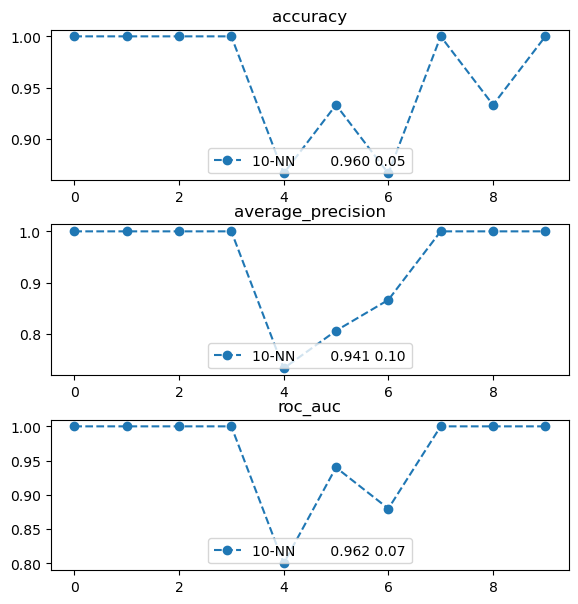

In [41]:
msrs = ['accuracy', 'average_precision', 'roc_auc']

fig, axes = plt.subplots(len(msrs), 1, figsize=(6, 2*len(msrs)))
fig.tight_layout()


for mod_name, model in classifiers.items():
    # abbreviate
    cvs = skms.cross_val_score
    cv_results = {msr:cvs(model, iris_onec_ftrs, iris_onec_tgt,
                          scoring=msr, cv=10) for msr in msrs}


for ax, msr in zip(axes, msrs):
    msr_results = cv_results[msr]
    my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name,
    msr_results.mean(),
    msr_results.std())

    ax.plot(msr_results, 'o--', label=my_lbl)
    ax.set_title(msr)
    ax.legend(loc='lower center', ncol=2)

we do see that there’s one CV-fold where Naive Bayes does really poorly  


### where precision comes from  / what roc looks like in this case:

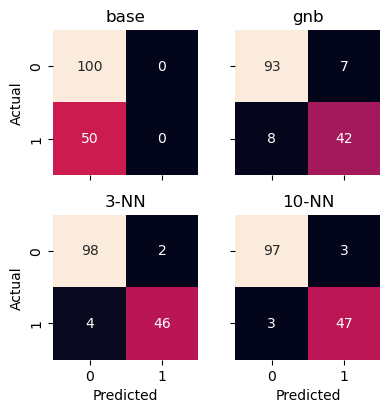

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True)
fig.tight_layout()


for ax, (mod_name, model) in zip(axes.flat, classifiers.items()):
    preds = skms.cross_val_predict(model, iris_onec_ftrs, iris_onec_tgt, cv=10)
    cm = metrics.confusion_matrix(iris.target==1, preds)
    sns.heatmap(cm, annot=True, ax=ax,
    cbar=False, square=True, fmt="d")
    
    ax.set_title(mod_name)

axes[1, 0].set_xlabel('Predicted')
axes[1, 1].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[1, 0].set_ylabel('Actual');

To dive into the ROC curves, we can make use of an argument to cross_val_predict
that lets us extract the classification scores directly from the aggregate cross-validation
classifiers. We do that with method='predict_proba' below. Instead of returning a single
class, we get back the class scores.

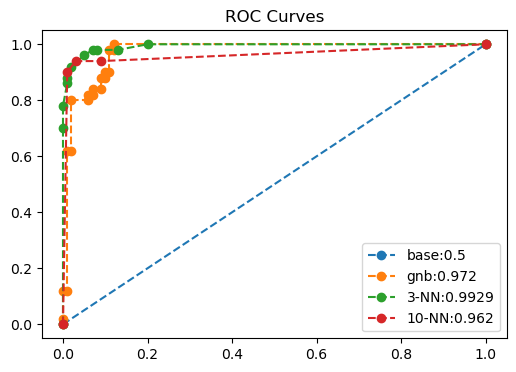

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cv_prob_true = {}

for mod_name, model in classifiers.items():
    cv_probs = skms.cross_val_predict(model, iris_onec_ftrs, iris_onec_tgt, cv=10, method='predict_proba')
    cv_prob_true[mod_name] = cv_probs[:, 1]
    fpr, tpr, thresh = metrics.roc_curve(iris_onec_tgt,
                                         cv_prob_true[mod_name])
    auc = metrics.auc(fpr, tpr)
    ax.plot(fpr, tpr, 'o--', label="{}:{}".format(mod_name, auc))

ax.set_title('ROC Curves')
ax.legend();

based on roc we are probably most interested in our 3-NN model right
now because of its slightly better AUC. We’ll make use of the `cv_prob_trues` from last
example to create our lift curve:

Text(0.5, 1.0, 'Lift versus Random')

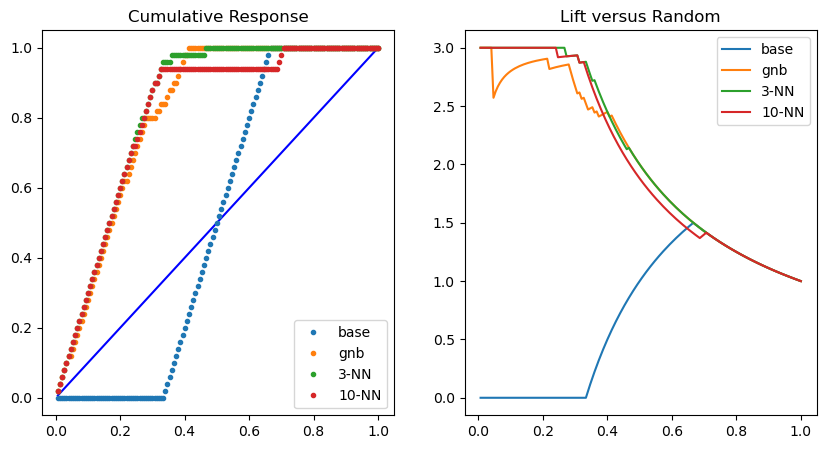

In [44]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10, 5))

N = len(iris_onec_tgt)
xs = np.linspace(1/N, 1, N)
ax1.plot(xs, xs, 'b-')

for mod_name in classifiers:
    # negate so big values come first
    myorder = np.argsort(-cv_prob_true[mod_name])
    # cumulative sum then to percent (last value is total)
    realpct_myorder = iris_onec_tgt[myorder].cumsum()
    realpct_myorder = realpct_myorder / realpct_myorder[-1]
    ax1.plot(xs, realpct_myorder, '.', label=mod_name)
    ax2.plot(xs,realpct_myorder / np.where(xs > 0, xs, 1), label=mod_name)

ax1.legend()
ax2.legend()
ax1.set_title("Cumulative Response")
ax2.set_title("Lift versus Random")

### dataset for the other notebook

The data(set) comes from:
> Cortez, P. and Silva, A. “Using Data Mining to Predict Secondary School Student  
> Performance.” In: A. Brito and J. Teixeira (eds), Proceedings of 5th FUture BUsiness
> TEChnology Conference (FUBUTEC 2008), pp. 5-12, Porto, Portugal, April, 2008,
EUROSIS.

In [46]:
student_url = ('https://archive.ics.uci.edu/' +
'ml/machine-learning-databases/00320/student.zip')
def grab_student_numeric_discrete():
    # download zip file and unzip
    # unzipping unknown files can be a security hazard
    import urllib.request, zipfile
    urllib.request.urlretrieve(student_url, 'port_student.zip')
    zipfile.ZipFile('port_student.zip').extract('student-mat.csv')

    # preprocessing
    df = pd.read_csv('student-mat.csv', sep=';')

    # g1 & g2 are highly correlated with g3;
    # dropping them makes the problem significantly harder
    # we also remove all non-numeric columns
    # and discretize the final grade by 0-50-75-100 percentile
    # which were determined by hand
    df = df.drop(columns=['G1', 'G2']).select_dtypes(include=['number'])
    df['grade'] = pd.cut(df['G3'], [0, 11, 14, 20], labels=['low', 'mid', 'high'], include_lowest=True)
    df.drop(columns=['G3'], inplace=True)

    # save as
    df.to_csv('portugese_student_numeric_discrete.csv', index=False)

In [47]:
grab_student_numeric_discrete()